**Problem 2**

You want to maintain the temperature of a room. You want to maintain the speed of a mechanism under varying loads. You want to maintain the heading of a robot on imperfect terrain. You want your drone to remain parallel with the ground to maintain balance.

All of these are control problems. You want to maintain a **stable state**, while natural imperfections fight you. 

Let's first consider the temperature problem and say you want to keep the room at a temperature greater than or equal to $25 \degree \text{C}$. A simple way to do so is to turn on the AC if it's hotter than that, and turn it off if it's cooler. The controller output $u(t)$ at any point in time would be:
$$
u(t) = 
\begin{cases}
1 & \text{if} \; T \geq 25 \degree \text{C} \\
0 & \text{if} \; T < 25 \degree \text{C}
\end{cases}
$$

This is called a **bang-bang controller**, also known as a 2-step, or on-off controller. The idea is simple: only act if the state is not what you want. You have a reference point, called the **setpoint** ($SP$), and the actual sensor value, the **process valuable** ($PV$). We simply measure $PV$ relative to $SP$. Then, we can very easily implement it as such:

In [ ]:
class NaiveBangBang:
    def __init__(self, setpoint):
        self.setpoint = setpoint

    def control(self, current_value):
        if current_value >= self.setpoint:
            return 1
        else:
            return 0

In this model, we simulate our AC unit to have a maximum cooling rate of $u_{max} \degree \text{C} /\text{s}$. 

We also model the heat exchange of the room as:
$$
\dfrac{dT}{dt} = -\dfrac{T - T_{ambient}}{\tau} + u + d
$$
where:
- $T(t)$ is the temperature of the room at time t
- $T_{ambient}$ is the ambient temperature
- $\tau$ is the thermal time constant of the system
- $u$ is the control input
- $d \sim \mathcal{N}(0, \sigma^2)$ is random disturbance noise, sampled from a Gaussian distribution

Discretising it, we yield the equation:
$$
T_{k+1} = T_{k} + \left(-\dfrac{T_{k}-T_{ambient}}{\tau} + u + d \right)\Delta t
$$

Then we can visualise the temperature over time:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01  # Time step
time = 10  # Total simulation time
t = np.arange(0, time, dt)

# System state
temp = np.zeros_like(t)  # temperature
u = np.zeros_like(t)  # control input

# Initial conditions
temp[0] = 30

# Desired temperature
target = 25

# Bang-bang parameters
u_max = 5.0  # Maximum control input (e.g., heater power)

# Simulation
for k in range(len(t) - 1):
    error = target - temp[k]

    # Bang-bang controller
    if error < 0:
        u[k] = -u_max
    else:
        u[k] = 0

    # System dynamics with disturbance
    disturbance = np.random.normal(0, 1)
    tau = 1.0  # Thermal time constant
    ambient_temp = 30  # Ambient temperature

    temp[k + 1] = temp[k] + (-(temp[k] - ambient_temp) / tau + u[k] + disturbance) * dt


# Plotting

fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)

ax.plot(t, temp, label="Temperature")
ax.axhline(target, color="r", linestyle="--", label="Setpoint")
ax.set_ylabel("Temperature (°C)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

Messing around with the values and you'll see something fun: If you let $u_{max}$ be too small, the system never reaches the desired state. Specifically, if 
$$
u_{max} < \left(-\dfrac{T - T_{ambient}}{\tau} + d\right)_{max}
$$
then the system **doesn't have enough control authority**. Simply, it means that the actuator isn't strong enough to combat the disturbances. In those cases, the controller will saturate, and the system maintains relative balance around the steady state error 
$$
-\dfrac{T - T_{ambient}}{\tau} + u_{max} + d
$$
Looking closely around the setpoint, you'd also see a lot of switching on and off. This is called **chattering**, and in some cases it can be a bad thing. With IC switches and power electronics some controllers do rely on this constant switching, but if you use mechanical relays or simpler mechanical switches, it is generally better to remove it. 

We can do this by applying a deadband around the setpoint. This just means a band of values around $SP$ where the state is acceptable, and we don't need the control input. Also, we can use three states: $u_{max}$, 0, and $-u_{max}$. This would be equivalent to a room with an AC and a heater trying to keep the temperature around $24 - 26 \degree \text{C}$. Mathematically, we can write:

$$
u(t) = 
\begin{cases}
u_{max} & \text{if} \; e(t) \geq \delta  \\
0 & \text{if} \; |e(t)| < \delta  \\
-u_{max} & \text{if} \; e(t) \leq -\delta  \\
\end{cases}
$$
where $e(t)$ is the error function and $e(t) = SP - PV$. Graphically, it looks like this:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 400)
setpoint = 0
deadband = 1
y = x
u = np.zeros_like(x)

for i in range(len(x)):
    if y[i] >= setpoint + deadband:
        u[i] = 1  # Actuator MAX
    elif y[i] <= setpoint - deadband:
        u[i] = -1  # Actuator MIN
    else:
        u[i] = 0  # Actuator OFF

fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)

ax.plot(x, u, label="Output Signal")
ax.axhline(setpoint, color="r", linestyle="--", label="Setpoint")
ax.set_ylabel("Output Signal")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

This concept of a deadband is used a lot to minimise jitter and noise around a certain setpoint. But in our case, it doesn't really solve the problem of chattering:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from common.feedback import BangBang

dt = 0.01  # Time step
time = 10  # Total simulation time
t = np.arange(0, time, dt)

# System state
temp = np.zeros_like(t)  # temperature
u = np.zeros_like(t)  # control input

temp[0] = 30
target = 25

controller = BangBang(setpoint=target, deadband=1.0, u_max=5.0, u_min=-5.0)

# Simulation
for k in range(len(t) - 1):
    u[k] = controller.control(current_value=temp[k])

    # Dynamics of the system
    disturbance = np.random.normal(0, 1)
    tau = 1.0  # Thermal time constant
    ambient_temp = 30  # Ambient temperature

    temp[k + 1] = temp[k] + (-(temp[k] - ambient_temp) / tau + u[k] + disturbance) * dt

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)
ax.plot(t, temp, label="Temperature")
ax.axhline(target, color="r", linestyle="--", label="Setpoint")
ax.set_ylabel("Temperature (°C)")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

As you can see, it just moves the chattering from around $SP$ to around $SP + \delta$. We need a better way to model the controller. 

If the controller reaches the deadband and it stops acting, our system dynamics forces it to move out of the deadband too quickly. It needs to still be acting, even after it's in the deadband. We propose a model like this:

$$
u(t) = 
\begin{cases}
u_{max} & \text{if} \; e(t) \geq \delta  \\
u(t^-) & \text{if} \; |e(t)| < \delta  \\
-u_{max} & \text{if} \; e(t) \leq -\delta  \\
\end{cases}
$$
where $u(t^-)$ is the state of the controller right before time $t$. Then the implementation and dynamics are as follows:

In [ ]:
class BangBang2:
    def __init__(self, setpoint, deadband=1.0):
        self.setpoint = setpoint
        self.deadband = deadband
        self.previous_output = 0

    def control(self, current_value):
        error = self.setpoint - current_value

        if error > self.deadband:
            self.previous_output = 1
        elif error < -self.deadband:
            self.previous_output = -1

        return self.previous_output

This is **hysteresis**, and it's the first control system we've derived with memory. It remembers the previous state, and the system stays in a dynamic balance. Our system dynamics trend upward naturally, so it produces a near periodic oscillation around the setpoint. Mess around with different system dynamics, and even randomness, to see how the control system behaves.

For continuously regulating a quantity such as temperature or speed, we've reached the practical limit of bang-bang control. To achieve smoother and more accurate regulation, we need a controller whose output can vary continuously. But the ideas from hysteresis control can be distilled to design a better controller:
- Produce enough corrective action.
- Use information from the past when beneficial.
- React intelligently to how the error evolves. 

With this, let us introduce another problem:

**Problem 2.1**: A flywheel stores rotational energy for a robot shooter. Every time the robot launches a game piece, the flywheel loses energy and its speed drops. To keep every shot consistent, the flywheel should return to its target speed as quickly as possible. How do we design such a controller?

First, we model the system dynamics. Starting from Newton's 2nd law for rotation, we have:
$$ I = \tau \alpha$$
where 
- $I$ is the moment of inertia
- $\tau$ is the net torque
- $\alpha = \dot{\omega} $ is angular acceleration

We can model the net torque to be the motor torque minus friction, load torque, and some disturbance, so:
$$
\tau = \tau_m - \tau_f - \tau_l + d
$$
Now we make sense of each of those terms. $\tau_m$ will be our control ouput at each time $u(t)$. As for friction, we can model it as viscous damping: the key idea is that resistance is proportional to speed. In angular form, we can choose a damping coefficient $b$ such that:
$$ \tau_f = b \omega$$
For the load, let's say the flywheel shooter launches a game piece periodically, and randomly. Each launched game piece removes energy from the flywheel. In reality, this interaction is an impulse occurring over a very short contact time. For simplicity, we approximate it as a constant load torque applied for a short duration. This produces the same qualitative speed drop while keeping the model easy to understand and simulate. Mathematically, we can define this randomness with a random variable. Define:
$$ X_k \sim \text{Bernoulli}(p)$$
then
$$ \tau_l =
\begin{cases}
\text{const} & \; \text{if} \; X_k = 1 \\
0 & \; \text{if} \; X_k = 0
\end{cases}
$$
Finally, we arrive at the differential equation of the system:
$$
I \dot{\omega} = \tau_m - b \omega - \tau_l + d 
$$
Rearranging and discretising gives:
$$
\omega_{k+1} = \omega_{k} + \left( -\dfrac{b}{I}\omega_k + \dfrac{u}{I} - \dfrac{\tau_l}{I} X_k + d_k \right) \Delta t
$$

Now to design the controller. Bang-bang control treats every error the same. Whether the flywheel is 1 RPM or 1000 RPM below the target, it commands the motor at full power. Intuitively, we'd rather apply a correction proportional to how wrong the system is. So let's start with a proportional controller as follows:
$$
u(t) = K_p e(t)
$$
where $K_p$ is a tunable parameter for proportionality. Applying this, we can see:



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01  # Time step
time = 20.0  # Total simulation time
t = np.arange(0, time, dt)

# System state
v = np.zeros_like(t)  # angular velocity
u = np.zeros_like(t)  # control input
load = np.zeros_like(t)

# Initial conditions
v[0] = 0

# Desired angular velocity
target = 10

# Maximum control input
u_max = 20.0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the flywheel
r = 0.5  # Radius of the flywheel
inertia = 0.5 * m * r**2  # Moment of inertia of the flywheel

p = 0.01  # Probability of a shot torque disturbance

# Stochastic shot disturbance parameters
shot_timer = 0.0
shot_duration = 0.1  # seconds
shot_torque = 5.0  # Torque applied during a shot
shot_rate = 0.5  # average shots per second

# Simulation
for k in range(len(t) - 1):
    error = target - v[k]

    # P controller
    Kp = 1.0  # Proportional gain
    u[k] = Kp * error

    # Limit the control input
    u[k] = np.clip(u[k], -u_max, u_max)

    if shot_timer <= 0 and np.random.rand() < shot_rate * dt:
        shot_timer = shot_duration

    # Apply the load
    if shot_timer > 0:
        load[k] = shot_torque
        shot_timer -= dt
    else:
        load[k] = 0

    ambient_disturbance = np.random.normal(0, 1)

    v[k + 1] = v[k] + ((-b * v[k] / inertia) + (u[k] / inertia) + (-load[k] / inertia) + ambient_disturbance) * dt

# Plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, v)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Velocity")

ax2.step(t, load, where="post")
ax2.set_ylabel("Load Torque")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

Looking at this, we can see that the system actually never reaches the desired state. This is easy to see from the math: as we get closer, the error shrinks down near zero, and so the correction term also shrinks to zero. The system settles down at a steady state error. We need a way to measure this error even as it shrinks down, and apply a correction accordingly. The longer we've been wrong for and the more wrong we are, the stronger the correction. Then, we propose the proportional-integral controller:
$$
u(t) = K_p e(t) + K_i \int e(t)dt
$$
The integral term does exactly what we want: it accumulates error over time, and corrects the system accordingly. To visualise:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01  # Time step
time = 20.0  # Total simulation time
t = np.arange(0, time, dt)

# System state
v = np.zeros_like(t)  # angular velocity
u = np.zeros_like(t)  # control input
load = np.zeros_like(t)

# Initial conditions
v[0] = 0

# Desired angular velocity
target = 10

# Maximum control input
u_max = 20.0
integral = 0.0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the flywheel
r = 0.5  # Radius of the flywheel
inertia = 0.5 * m * r**2  # Moment of inertia of the flywheel

p = 0.01  # Probability of a shot torque disturbance

# Stochastic shot disturbance parameters
shot_timer = 0.0
shot_duration = 0.1  # seconds
shot_torque = 5.0  # Torque applied during a shot
shot_rate = 0.5  # average shots per second

# Simulation
for k in range(len(t) - 1):
    error = target - v[k]
    integral += error * dt

    # P controller
    Kp = 5  # Proportional gain
    K_i = 1  # Integral gain
    u[k] = Kp * error + K_i * integral

    # Limit the control input
    u[k] = np.clip(u[k], -u_max, u_max)

    if shot_timer <= 0 and np.random.rand() < shot_rate * dt:
        shot_timer = shot_duration

    # Apply the load
    if shot_timer > 0:
        load[k] = shot_torque
        shot_timer -= dt
    else:
        load[k] = 0

    ambient_disturbance = np.random.normal(0, 1)

    v[k + 1] = v[k] + ((-b * v[k] / inertia) + (u[k] / inertia) + (-load[k] / inertia) + ambient_disturbance) * dt

# Plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, v)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Velocity")

ax2.step(t, load, where="post")
ax2.set_ylabel("Load Torque")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

That looks better. In the scope of this simulation, everything works fine. However, there's a failure mode silently hiding: when we're far from the setpoint, the controller will see a massive error. The controller doesn't know the motor's limits: it computed some large commanded value, the actuator physically can't deliver it, but the integral term keeps accumulating error every timestep as if the full commanded value was applied. The integral term grows unboundedly while saturated, way past the point where it's doing anything useful.

The consequence appears when the error reverses sign. Even though the process variable has crossed the setpoint and the P term now wants to reverse the control input, the bloated integral term is still enormous and pointing the wrong way. The controller has to "unwind" all that excess accumulation before it can respond to the new error direction, producing a large, sluggish overshoot that has nothing to do with your tuning and everything to do with this accounting error:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01
time = 20.0
t = np.arange(0, time, dt)

v = np.zeros_like(t)
u = np.zeros_like(t)
integral = np.zeros_like(t)

v[0] = 0
target = 40
u_max = 5.0   # deliberately restrictive, forces long saturation

b = 0.1
m = 2.0
r = 0.5
inertia = 0.5 * m * r**2

Kp = 5.0
Ki = 2.0

for k in range(len(t) - 1):
    error = target - v[k]
    integral[k] = integral[k-1] + error * dt if k > 0 else error * dt

    u_raw = Kp * error + Ki * integral[k]
    u[k] = np.clip(u_raw, -u_max, u_max)

    v[k+1] = v[k] + (-b * v[k] / inertia + u[k] / inertia) * dt

u[-1] = u[-2] 
integral[-1] = integral[-2]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
ax1.plot(t, v)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Velocity")

ax2.step(t, u, where="post")
ax2.axhline(u_max, color="gray", linestyle=":")
ax2.set_ylabel("Control Input (clamped)")

ax3.plot(t, integral)
ax3.set_ylabel("Raw Integral Accumulator")
ax3.set_xlabel("Time")

plt.tight_layout()
plt.show()

Watch the third subplot: the raw integral accumulator keeps climbing long after $u$ has been pinned at $u_{max}$, and it keeps climbing even after $v$ overshoots past the target, because the controller is still measuring positive error contribution from the saturated period, faster than the now-negative error can cancel it out. The velocity plot shows a visible overshoot-and-settle that a correctly anti-wound-up controller wouldn't produce.

Fixing it: **conditional integration** (clamping the integrator)

The simplest fix is to stop accumulating the integral whenever the controller is saturated and the error would push it further into saturation. If the error would pull it back out of saturation, keep integrating normally.

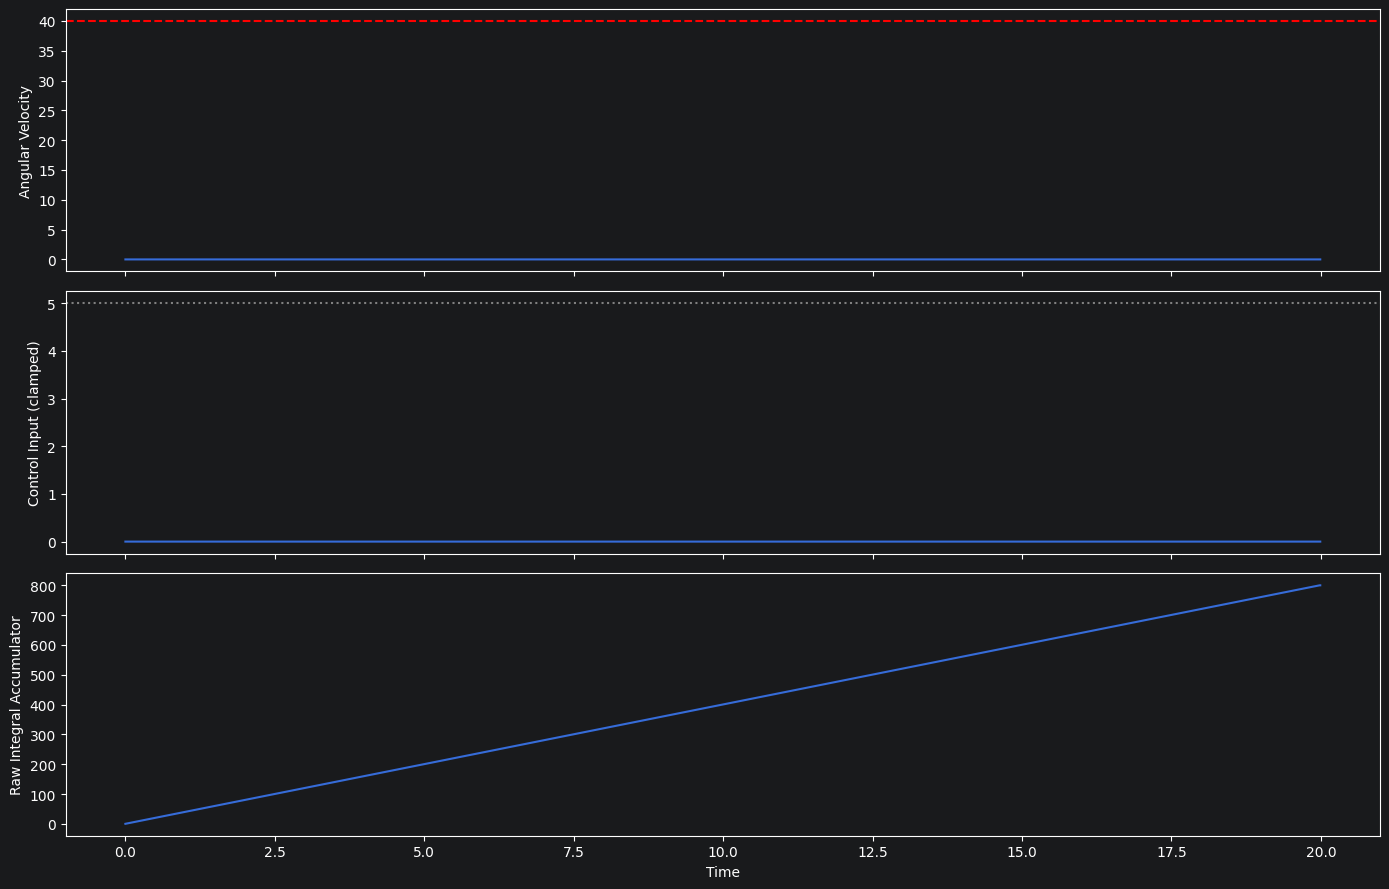

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from common.feedback import PID

dt = 0.01
time = 20.0
t = np.arange(0, time, dt)

v = np.zeros_like(t)
u = np.zeros_like(t)
integral = np.zeros_like(t)

v[0] = 0
target = 40
u_max = 5.0   # deliberately restrictive, forces long saturation

b = 0.1
m = 2.0
r = 0.5
inertia = 0.5 * m * r**2

Kp = 5.0
Ki = 2.0

pid = PID(5.0, 2.0, 0.0, 0.0, u_max, -u_max)

for k in range(len(t) - 1):
    error = target - v[k]
    integral[k] = integral[k-1] + error * dt if k > 0 else error * dt

    dv = (v[k] - v[k-1]) / dt
    u[k] = pid.control(v[k], dv, dt)

    v[k+1] = v[k] + (-b * v[k] / inertia + u[k] / inertia) * dt

u[-1] = u[-2] 
integral[-1] = integral[-2]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
ax1.plot(t, v)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Velocity")

ax2.step(t, u, where="post")
ax2.axhline(u_max, color="gray", linestyle=":")
ax2.set_ylabel("Control Input (clamped)")

ax3.plot(t, integral)
ax3.set_ylabel("Raw Integral Accumulator")
ax3.set_xlabel("Time")

plt.tight_layout()
plt.show()

But there are local dips in angular velocity where the flywheel shoots. We need to find a way for the controller to react to these quick, local changes. An intuitive way is to measure the rate of change. If the error changes quickly, correct accordingly. We now have the full **proportional-integral-derivative** (PID) controller:
$$
u(t) = K_p e(t) + K_i \int e(t)dt + K_d \dfrac{de}{dt}
$$

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from common.disturbance import SquareWaveDisturbance
from common.feedback import PID

dt = 0.01  # Time step
time = 20.0  # Total simulation time
t = np.arange(0, time, dt)

# System state
v = np.zeros_like(t)  # angular velocity
a = np.zeros_like(t)  # angular acceleration
u = np.zeros_like(t)  # control input
load = np.zeros_like(t)
v[0] = 0
a[0] = 0

# Desired angular velocity
target = 10

# Maximum control input
u_max = 20.0
integral = 0.0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the flywheel
r = 0.5  # Radius of the flywheel
inertia = 0.5 * m * r**2  # Moment of inertia of the flywheel

shot = SquareWaveDisturbance(shot_rate=0.5, shot_duration=0.1, shot_torque=5.0)

controller = PID(Kp=5.0, Ki=1.0, Kd=0.2, alpha=0.0, u_max=u_max, u_min=-u_max, setpoint=target)

# Simulation
for k in range(len(t) - 1):
    load[k] = shot.update(dt)
    ambient_disturbance = np.random.normal(0, 0.1)

    a[k] = (u[k] - b * v[k] - load[k] - ambient_disturbance) / inertia

    u[k + 1] = controller.control(v[k], a[k], dt)

    a[k + 1] = (u[k + 1] - b * v[k] - load[k]) / inertia
    v[k + 1] = v[k] + a[k + 1] * dt

# Plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, v)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Velocity")

ax2.step(t, load, where="post")
ax2.set_ylabel("Load Torque")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

Now we can react to the errors. Still not perfect though. Notice how in the simulation, we added a background disturbance term. If we increase $K_d$ too much, or the background disturbance is too great, the derivative term dominates and reacts to noise. The controller would then oscillate around the setpoint. To counteract this, we have to "smooth" out the noise. We can do so using an **Exponential Moving Average** (EMA) filter. Essentially, it is a low-pass filter: it blocks high frequency noise from contaminating the controller inputs. The formula is as follows:
$$
y_k = \alpha y_{k-1} + (1-\alpha)x_k
$$
where $x_k$ is the sensor reading, and $y_{k-1}$ is the previous filtered output. A high $\alpha$ means that the filter biases towards historical data. It reacts more slowly, but more resistant to noise. A lower alpha means it stays closer to the sensor reading, but easily corruptible by noise.

Also, throughout our example, we maintain the speed at a constant. But real world systems sometimes need changing targets. Our derivative term might pick up on this sudden change and interpret it as the error. This is called *derivative kick*. We can eliminate this by changing a small part of the math. Because:
$$
e(t) = \omega_{target} - \omega(t)
$$
differentiating both sides with respect to time yields:
$$
\dfrac{de}{dt} = \dfrac{d \omega_{target}}{dt} - \dfrac{d \omega}{dt}
$$
Because our setpoint is constant, we can omit the first term. The code implementation is exactly as the given formula:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from common.feedback import PID

dt = 0.01  # Time step
time = 20.0  # Total simulation time
t = np.arange(0, time, dt)

# System state
v = np.zeros_like(t)  # angular velocity
a = np.zeros_like(t)  # angular acceleration
u = np.zeros_like(t)  # control input
load = np.zeros_like(t)
v[0] = 0
a[0] = 0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the flywheel
r = 0.5  # Radius of the flywheel
inertia = 0.5 * m * r**2  # Moment of inertia of the flywheel

target = 10.0 

shot = SquareWaveDisturbance(shot_rate=0.5, shot_duration=0.1, shot_torque=5.0)

controller = PID(Kp = 8.0, Ki = 0.5, Kd = 3.0, alpha = 0.9, u_max=20.0, u_min=-20.0, setpoint = target)

# Simulation
for k in range(len(t) - 1):
    load[k] = shot.update(dt)
    ambient_disturbance = np.random.normal(0, 0.1)

    a[k] = (u[k] - b * v[k] - load[k] - ambient_disturbance) / inertia

    u[k + 1] = controller.control(v[k], a[k], dt)

    a[k + 1] = (u[k + 1] - b * v[k] - load[k]) / inertia
    v[k + 1] = v[k] + a[k + 1] * dt

# Plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, v)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Velocity")

ax2.step(t, load, where="post")
ax2.set_ylabel("Load Torque")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

Really though, this is the limits of what a PID control can do. The given example illustrated some common failure modes of this controller, to a first order system:
- Steady state error (P only)
- Unresponsiveness (PI only)
- Noise disturbance (full PID)
- And even overshoot (if you let $K_i$ be too high)

But there are only so many failure modes to analyse in a first order system. To understand other failure modes, we need to understand the dynamics of higher order systems. Consider a rigid arm moving around the pivot. Its dynamics is given by the equation:
$$
I \ddot{\theta} = u - b \dot{\theta} - mg\dfrac{l}{2} \cos{\theta} + d
$$
Discretising gives:
$$
\omega_{k+1} = \omega_k + \dfrac{u_k - b \omega_k - mg\dfrac{l}{2} \cos \theta_k + d}{I}\Delta t
$$
We'll also use symplectic Euler integration to calculate angular position and velocity:
$$
\omega_{k+1} = \omega_{k} + \alpha_k \Delta t \\
\theta_{k+1} = \theta_{k} + \omega_{k+1} \Delta t
$$
The $\omega_{k+1}$ term is so that we can react to changes in the velocity quickly enough, or the simulation might not be true to the real phenomenon.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from common.disturbance import SquareWaveDisturbance
from common.feedback import PID

dt = 0.01  # Time step
time = 20.0  # Total simulation time
t = np.arange(0, time, dt)

# System state
theta = np.zeros_like(t)
omega = np.zeros_like(t)
u = np.zeros_like(t)  # control input

theta[0] = np.pi / 2
omega[0] = 0.0

target = 0.0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the arm
length = 0.5  # Length of the arm
g = 9.81  # Acceleration due to gravity
inertia = (1 / 3) * m * length**2  # Moment of inertia of the arm

ambient_disturbance = np.random.normal(0, 0.1)

shot = SquareWaveDisturbance(shot_rate=0.5, shot_duration=0.1, shot_torque=5.0)

controller = PID(Kp = 30.0, Ki = 15.0, Kd = 25.0, alpha = 0.9, u_max=20.0, u_min=-20.0, setpoint = target)

# Simulation
for k in range(len(t) - 1):
    u[k] = controller.control(theta[k], omega[k], dt=dt)

    # Angular acceleration
    theta_ddot = (u[k] - b * omega[k] - m * g * (length / 2) * np.cos(theta[k]) + ambient_disturbance) / inertia

    # Euler integration
    omega[k + 1] = omega[k] + theta_ddot * dt
    theta[k + 1] = theta[k] + omega[k + 1] * dt

u[-1] = u[-2]  # Last control input value for plotting

# Plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, theta)
ax1.axhline(target, color="r", linestyle="--")
ax1.set_ylabel("Angular Position")

ax2.step(t, u, where="post")
ax2.set_ylabel("Control Input")
ax2.set_xlabel("Time")

plt.tight_layout()
plt.show()

Tuning this was much more difficult than the flywheel system, for one simple reason: the system dynamics are second order. The plant itself possesses oscillatory modes that simply do not exist in first-order systems.. All systems have a combination of these two modes. A P only controller here makes the system oscillate around a fixed point instead of giving us a steady state error. Try to reset the three PID parameters and retune it from scratch. Maybe turn off the random disturbance first. Maybe be careful of the integral term dominating because the controller might take a while to settle. The integral might keep accumulating too much and causes **integral windup**.

Also, notice how the arm droops below $0$ first before settling. PID alone, locally, cannot account for the torque at the horizontal angle. If the controller knows to cancel that torque, it'd be much better.

This is a classic example of how and where PID alone isn't enough. With **higher order systems**, the dynamics are more interdependent and a single PID loop might not be able to keep up. We will need better ways to control the motion.

Another way to try experimenting with this simulation is to try changing the $\theta$ angle that we want to hold. Notice that the $\sin \theta$ term makes this system nonlinear. For an LTI (linear time invariant) system, one set of PID gains will work for any target. Near any operating angle, we can approximate $\sin \theta \approx \theta$, producing a local linear model. PID tuning is therefore often performed around one operating point. Change the angle and the gains we picked will not work as well for it anymore. So, the second place PID fails is in systems with high non-linearity, and for systems where time invariance fails. 

Time invariance means that the dynamics of the system doesn't change through time. If the robot arm picks up something, then the dynamics change. The mass term has changed, and we need another set of gains for this configuration. In factories for example, we weigh the parts beforehand and tune the arm while it moves with the part in hand. When the arm holds the part, the controller simply changes the PID gains. This technique is called **gain scheduling**.

So for first order systems such as the room with changing temperature, using hysteresis is good enough. For many first-order engineering systems, PID provides excellent performance. We might need more advanced control techniques, but for now: **Problem solved**.